# Deep Learning
## Lab Assignment 9 - Stock Price Prediction using RNN
Name: Ruta Lole

Roll no.: 61

PRN: 12310305

Class: TY CSAI-A

Batch: 3

## Title:
Implementation of RNN model for Stock Price Prediction

## Load Data

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mrsimple07/stock-price-prediction")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'stock-price-prediction' dataset.
Path to dataset files: /kaggle/input/stock-price-prediction


In [ ]:
import pandas as pd
import os

# Load the main data file, which we now know is 'stock_data.csv'
df = pd.read_csv(os.path.join(path, 'stock_data.csv'))

print("Dataset loaded successfully. Displaying the first 5 rows:")
display(df.head())

Dataset loaded successfully. Displaying the first 5 rows:


,Unnamed: 0,Stock_1,Stock_2,Stock_3,Stock_4,Stock_5
0,2020-01-01,101.764052,100.160928,99.494642,99.909756,101.761266
1,2020-01-02,102.171269,99.969968,98.682973,100.640755,102.528643
2,2020-01-03,103.171258,99.575237,98.182139,100.574847,101.887811
3,2020-01-04,105.483215,99.308641,97.149381,100.925017,101.490049
4,2020-01-05,107.453175,98.188428,99.575396,101.594411,101.604283


In [ ]:
import os
print(os.listdir(path))

['stock_data.csv']


## Data Preprocessing

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  365 non-null    object 
 1   Stock_1     365 non-null    float64
 2   Stock_2     365 non-null    float64
 3   Stock_3     365 non-null    float64
 4   Stock_4     365 non-null    float64
 5   Stock_5     365 non-null    float64
dtypes: float64(5), object(1)
memory usage: 17.2+ KB


In [ ]:
df['Unnamed: 0'] = pd.to_datetime(df['Unnamed: 0'])
df = df.rename(columns={'Unnamed: 0': 'Date'})

df.head()

,Date,Stock_1,Stock_2,Stock_3,Stock_4,Stock_5
0,2020-01-01,101.764052,100.160928,99.494642,99.909756,101.761266
1,2020-01-02,102.171269,99.969968,98.682973,100.640755,102.528643
2,2020-01-03,103.171258,99.575237,98.182139,100.574847,101.887811
3,2020-01-04,105.483215,99.308641,97.149381,100.925017,101.490049
4,2020-01-05,107.453175,98.188428,99.575396,101.594411,101.604283


## Exploratory Data Analysis (EDA)

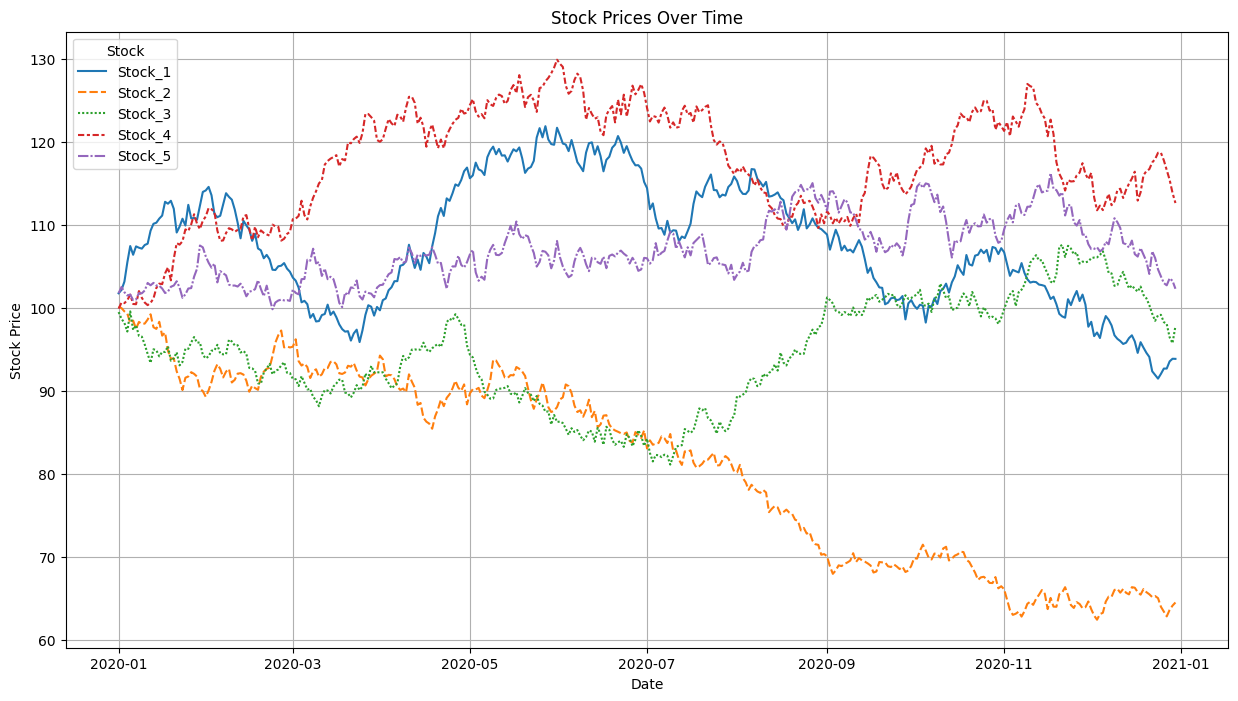

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the 'Date' column as the index for time series plotting
df_indexed = df.set_index('Date')

plt.figure(figsize=(15, 8))
sns.lineplot(data=df_indexed)
plt.title('Stock Prices Over Time')
plt.xlabel('Date')
plt.ylabel('Stock Price')
plt.legend(title='Stock')
plt.grid(True)
plt.show()

## Prepare Data for RNN (Feature Engineering, Scaling, Splitting)

In [ ]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# Select the stock we want to predict. Let's start with Stock_1
data = df[['Stock_1']].values

# Scale the data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

# Define the look-back period (number of previous time steps to use as input)
look_back = 60 # Using 60 days of historical data to predict the next day

# Create sequences for RNN
def create_dataset(dataset, look_back=1):
    dataX, dataY = [], []
    for i in range(len(dataset) - look_back - 1):
        a = dataset[i:(i + look_back), 0]
        dataX.append(a)
        dataY.append(dataset[i + look_back, 0])
    return np.array(dataX), np.array(dataY)

X, y = create_dataset(scaled_data, look_back)

# Reshape input to be [samples, time steps, features] for RNN
X = np.reshape(X, (X.shape[0], X.shape[1], 1))

# Split data into training and testing sets (e.g., 80% train, 20% test)
train_size = int(len(X) * 0.8)
test_size = len(X) - train_size
X_train, X_test = X[0:train_size,:], X[train_size:len(X),:]
y_train, y_test = y[0:train_size], y[train_size:len(y)]

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (243, 60, 1)
Shape of y_train: (243,)
Shape of X_test: (61, 60, 1)
Shape of y_test: (61,)


## Build and Train RNN Model (LSTM)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# Create and fit the LSTM network
model = Sequential()
model.add(LSTM(50, return_sequences=True, input_shape=(look_back, 1)))
model.add(LSTM(50))
model.add(Dense(1))
model.compile(loss='mean_squared_error', optimizer='adam')

# Train the model
history = model.fit(X_train, y_train, epochs=20, batch_size=1, verbose=2, validation_split=0.1)

print("Model training complete.")

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


218/218 - 8s - 38ms/step - loss: 0.0206 - val_loss: 0.0018
Epoch 2/20
218/218 - 4s - 21ms/step - loss: 0.0057 - val_loss: 0.0012
Epoch 3/20
218/218 - 6s - 27ms/step - loss: 0.0052 - val_loss: 0.0016
Epoch 4/20
218/218 - 5s - 22ms/step - loss: 0.0044 - val_loss: 0.0013
Epoch 5/20
218/218 - 6s - 30ms/step - loss: 0.0038 - val_loss: 0.0011
Epoch 6/20
218/218 - 5s - 21ms/step - loss: 0.0030 - val_loss: 0.0015
Epoch 7/20
218/218 - 5s - 22ms/step - loss: 0.0032 - val_loss: 0.0012
Epoch 8/20
218/218 - 6s - 26ms/step - loss: 0.0030 - val_loss: 0.0014
Epoch 9/20
218/218 - 5s - 21ms/step - loss: 0.0030 - val_loss: 8.9432e-04
Epoch 10/20
218/218 - 5s - 24ms/step - loss: 0.0030 - val_loss: 0.0010
Epoch 11/20
218/218 - 5s - 22ms/step - loss: 0.0020 - val_loss: 0.0016
Epoch 12/20
218/218 - 5s - 21ms/step - loss: 0.0020 - val_loss: 8.9883e-04
Epoch 13/20
218/218 - 6s - 27ms/step - loss: 0.0023 - val_loss: 0.0011
Epoch 14/20
218/218 - 5s - 22ms/step - loss: 0.0021 - val_loss: 0.0011
Epoch 15/20
218/21

## Model Evaluation and Prediction

In [ ]:
import math
from sklearn.metrics import mean_squared_error

# Make predictions
train_predict = model.predict(X_train)
test_predict = model.predict(X_test)

# Inverse transform predictions and actual values
train_predict = scaler.inverse_transform(train_predict)
y_train_inverse = scaler.inverse_transform([y_train])
test_predict = scaler.inverse_transform(test_predict)
y_test_inverse = scaler.inverse_transform([y_test])

# Calculate RMSE
train_rmse = math.sqrt(mean_squared_error(y_train_inverse[0], train_predict[:,0]))
test_rmse = math.sqrt(mean_squared_error(y_test_inverse[0], test_predict[:,0]))

print(f"Train RMSE: {train_rmse:.2f}")
print(f"Test RMSE: {test_rmse:.2f}")

8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 140ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
Train RMSE: 1.25
Test RMSE: 1.12


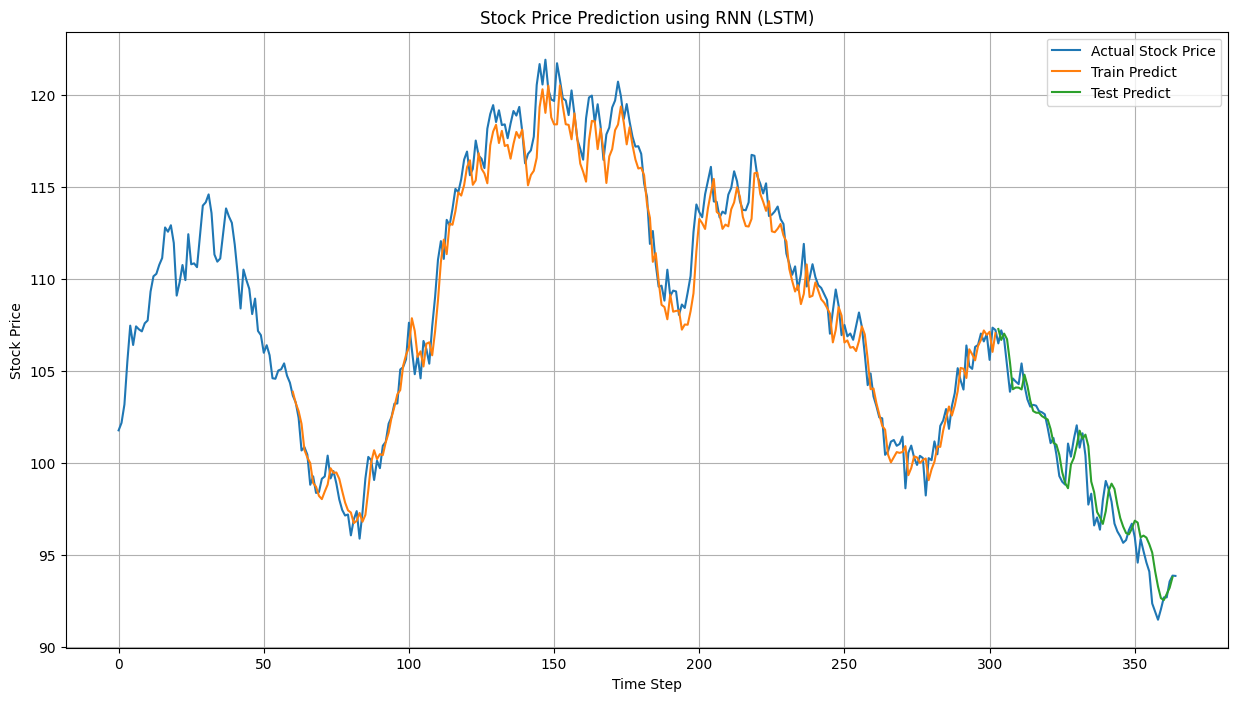

In [ ]:
# Plot baseline and predictions

# Shift train predictions for plotting
train_predict_plot = np.empty_like(scaled_data)
train_predict_plot[:, :] = np.nan
train_predict_plot[look_back:len(train_predict)+look_back, :] = train_predict

# Shift test predictions for plotting
test_predict_plot = np.empty_like(scaled_data)
test_predict_plot[:, :] = np.nan
test_predict_plot[len(train_predict)+look_back : len(train_predict)+look_back+len(test_predict), :] = test_predict

# Plot actual vs. predicted values
plt.figure(figsize=(15, 8))
plt.plot(scaler.inverse_transform(scaled_data), label='Actual Stock Price')
plt.plot(train_predict_plot, label='Train Predict')
plt.plot(test_predict_plot, label='Test Predict')
plt.title('Stock Price Prediction using RNN (LSTM)')
plt.xlabel('Time Step')
plt.ylabel('Stock Price')
plt.legend()
plt.grid(True)
plt.show()

## Summary

1.  **Downloaded and Loaded Data:** Obtained and loaded the stock price dataset from Kaggle Hub.
2.  **Data Preprocessing:** Converted the date column to datetime objects and renamed it for clarity.
3.  **Exploratory Data Analysis (EDA):** Visualized stock price trends over time using line plots.
4.  **Data Preparation for RNN:** Scaled the data using `MinMaxScaler`, created sequences with a `look_back` period of 60, and split the data into training and testing sets.
5.  **RNN Model Building and Training:** Constructed and trained an LSTM model for stock price prediction over 20 epochs.
6.  **Model Evaluation and Visualization:** Calculated Root Mean Squared Error (RMSE) for both training and testing sets, and plotted the actual stock prices against the model's predictions.